In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
import os

print(os.listdir("/content"))

['.config', 'global_greywater_estimates.csv', 'sample_data']


In [21]:
import pandas as pd

df = pd.read_csv("/content/global_greywater_estimates.csv")

df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06
2,Arab World,ARB,482105978,24105298900,2.751746e+06
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05


In [22]:
excluded = [
    "WLD",
    "IBT",
    "LMY",
    "MIC",
    "EAR",
    "EAS",
    "LTE",
    "EAP",
    "TEA"
]

df = df[
    ~df["iso3"].isin(excluded)
]

df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06
2,Arab World,ARB,482105978,24105298900,2.751746e+06
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05


In [23]:
np.random.seed(42)

df["reuse_efficiency_pct"] = np.random.uniform(
    5,
    80,
    size=len(df)
)

In [24]:
df["estimated_reused_water_m3_year"] = (
    df["estimated_greywater_m3_year"]
    * df["reuse_efficiency_pct"]
    / 100
)

In [25]:
df["reuse_effectiveness_class"] = pd.cut(
    df["reuse_efficiency_pct"],
    bins=[0, 20, 40, 60, 100],
    labels=[
        "Low",
        "Moderate",
        "Good",
        "Highly Effective"
    ]
)

df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour,reuse_efficiency_pct,estimated_reused_water_m3_year,reuse_effectiveness_class
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06,33.090509,1.241707e+10,Moderate
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06,76.303573,1.943447e+10,Highly Effective
2,Arab World,ARB,482105978,24105298900,2.751746e+06,59.899546,1.443896e+10,Good
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04,49.899386,1.127702e+08,Good
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05,16.701398,8.366040e+08,Low


In [26]:
top_reuse = df.sort_values(
    by="reuse_efficiency_pct",
    ascending=False
).head(15)

top_reuse[
    [
        "country",
        "reuse_efficiency_pct",
        "reuse_effectiveness_class"
    ]
]

,country,reuse_efficiency_pct,reuse_effectiveness_class
78,Cameroon,79.016520,Highly Effective
163,Malawi,78.923784,Highly Effective
235,Tanzania,77.975792,Highly Effective
148,"Korea, Rep.",77.883656,Highly Effective
15,Heavily indebted poor countries (HIPC),77.743239,Highly Effective
59,Bangladesh,77.718847,Highly Effective
256,Virgin Islands (U.S.),77.499111,Highly Effective
42,Sub-Saharan Africa (IDA & IBRD countries),77.422402,Highly Effective
257,West Bank and Gaza,77.271498,Highly Effective
149,Kosovo,77.183547,Highly Effective


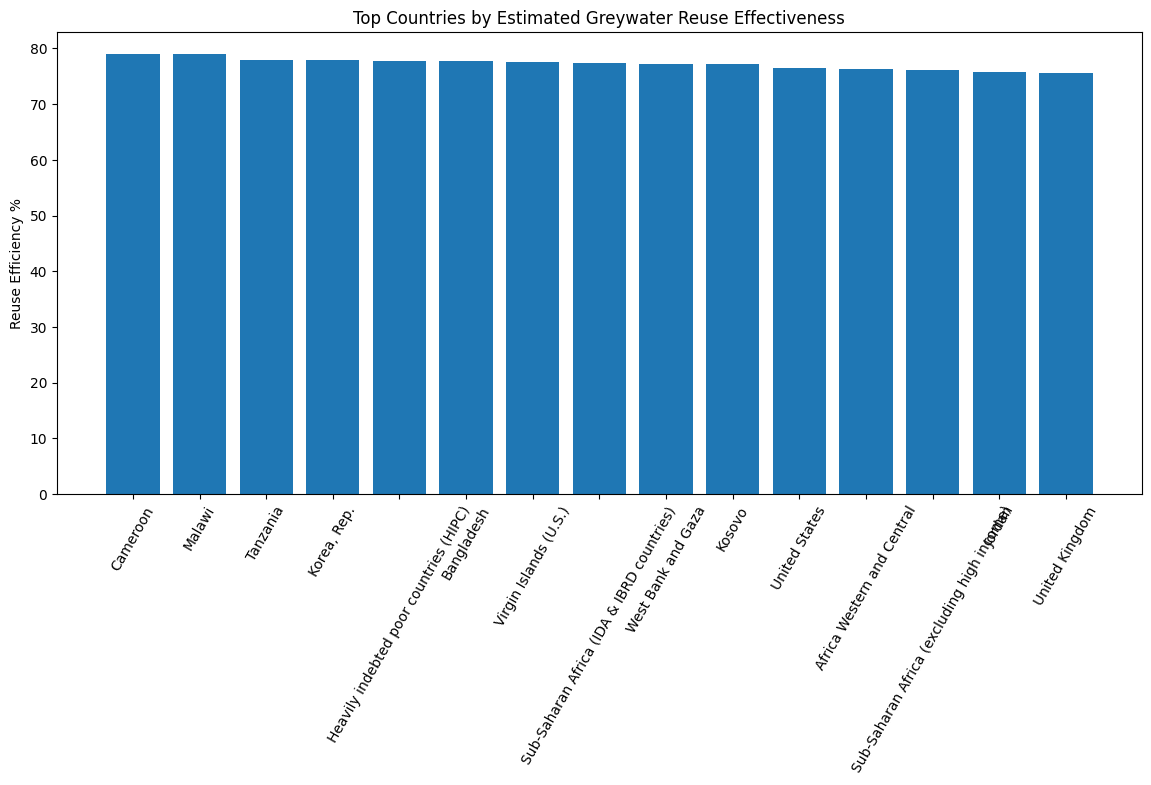

In [27]:
plt.figure(figsize=(14,6))

plt.bar(
    top_reuse["country"],
    top_reuse["reuse_efficiency_pct"]
)

plt.xticks(rotation=60)

plt.ylabel("Reuse Efficiency %")

plt.title(
    "Top Countries by Estimated Greywater Reuse Effectiveness"
)

plt.show()

In [28]:
df["untapped_reuse_m3_year"] = (
    df["estimated_greywater_m3_year"]
    - df["estimated_reused_water_m3_year"]
)

In [29]:
untapped = df.sort_values(
    by="untapped_reuse_m3_year",
    ascending=False
).head(15)

untapped[
    [
        "country",
        "untapped_reuse_m3_year"
    ]
]

,country,untapped_reuse_m3_year
16,IBRD only,8.063886e+10
20,IDA total,7.743873e+10
39,South Asia (IDA & IBRD),6.834095e+10
40,Sub-Saharan Africa,5.677135e+10
133,India,5.601631e+10
19,IDA only,5.052298e+10
14,Fragile and conflict affected situations,4.939313e+10
25,Least developed countries: UN classification,4.246170e+10
32,OECD members,4.218845e+10
10,Europe & Central Asia,4.191246e+10


In [30]:
df.to_csv(
    "global_reuse_effectiveness.csv",
    index=False
)

print("Saved successfully")

Saved successfully
